In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configurações ---
# Para melhor visualização dos plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7) # Define um tamanho padrão para os plots

# 1. Carrega o arquivo CSV com a codificação correta (utf-8)
df = pd.read_csv('News_Final.csv', encoding='utf-8')
print(f"Total de {len(df)} linhas e {len(df.columns)} colunas carregadas.")


Total de 93239 linhas e 11 colunas carregadas.


In [2]:

# 2. Limpeza e Preparação dos Dados
print("\n--- Limpando e Preparando os Dados ---")

# Converter 'PublishDate' para datetime
print("Convertendo 'PublishDate' para datetime...")
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')

# Tratar strings vazias em 'Topic' e 'Source'
print("Tratando strings vazias em 'Topic' e 'Source'...")
df['Topic'].replace('', 'Unknown', inplace=True)
df['Source'].replace('', 'Unknown', inplace=True)
print(f"Strings vazias em 'Topic' substituídas por 'Unknown': {(df['Topic'] == 'Unknown').sum()}")
print(f"Strings vazias em 'Source' substituídas por 'Unknown': {(df['Source'] == 'Unknown').sum()}")

# Tratar valores -1 nas colunas de redes sociais como NaN (Not a Number/Missing)
social_cols = ['Facebook', 'GooglePlus', 'LinkedIn']
print("Tratando valores '-1' nas colunas de redes sociais como NaN...")
for col in social_cols:
    # Certifica-se que a coluna é numérica antes de substituir
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(-1, np.nan)
    print(f"Valores -1 em '{col}' substituídos por NaN. Total de NaN: {df[col].isnull().sum()}")

# Garantir tipos numéricos para sentimentos
df['SentimentTitle'] = pd.to_numeric(df['SentimentTitle'], errors='coerce')
df['SentimentHeadline'] = pd.to_numeric(df['SentimentHeadline'], errors='coerce')





--- Limpando e Preparando os Dados ---
Convertendo 'PublishDate' para datetime...
Tratando strings vazias em 'Topic' e 'Source'...
Strings vazias em 'Topic' substituídas por 'Unknown': 0
Strings vazias em 'Source' substituídas por 'Unknown': 0
Tratando valores '-1' nas colunas de redes sociais como NaN...
Valores -1 em 'Facebook' substituídos por NaN. Total de NaN: 11602
Valores -1 em 'GooglePlus' substituídos por NaN. Total de NaN: 5744
Valores -1 em 'LinkedIn' substituídos por NaN. Total de NaN: 5745


C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\4264219350.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Topic'].replace('', 'Unknown', inplace=True)
C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\4264219350.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [3]:

# 3. Informações Básicas
print("\n--- Informações Básicas do DataFrame ---")
print("Primeiras 5 linhas:")
print(df.head())

print("\nInformações Gerais (Tipos de Dados, Valores Não-Nulos):")
df.info()

print("\nEstatísticas Descritivas (Colunas Numéricas):")
# Incluindo percentis para melhor entendimento da distribuição
print(df.describe(percentiles=[.01, .25, .5, .75, .99]))

print("\nContagem de Valores Ausentes por Coluna (após limpeza inicial):")
print(df.isnull().sum())



--- Informações Básicas do DataFrame ---
Primeiras 5 linhas:
    IDLink                                              Title  \
0  99248.0   Obama Lays Wreath at Arlington National Cemetery   
1  10423.0        A Look at the Health of the Chinese Economy   
2  18828.0   Nouriel Roubini: Global Economy Not Back to 2008   
3  27788.0                          Finland GDP Expands In Q4   
4  27789.0  Tourism, govt spending buoys Thai economy in J...   

                                            Headline  \
0  Obama Lays Wreath at Arlington National Cemete...   
1  Tim Haywood, investment director business-unit...   
2  Nouriel Roubini, NYU professor and chairman at...   
3  Finland's economy expanded marginally in the t...   
4  Tourism and public spending continued to boost...   

                                     Source    Topic         PublishDate  \
0                                 USA TODAY    obama 2002-04-02 00:00:00   
1                                 Bloomberg  economy 2008-

C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\3424501468.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis', order=topic_counts.index)



--- Análise de Tópicos ---
Contagem de Artigos por Tópico:
Topic
economy      33928
obama        28610
microsoft    21858
palestine     8843
Name: count, dtype: int64


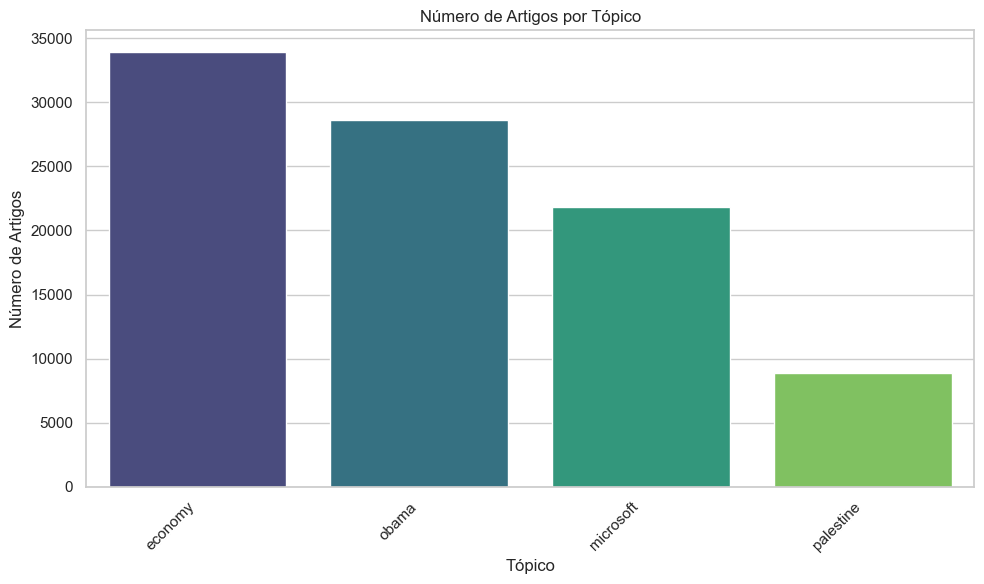

In [4]:
# 4. Análise de Tópicos
print("\n--- Análise de Tópicos ---")
topic_counts = df['Topic'].value_counts()
print("Contagem de Artigos por Tópico:")
print(topic_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis', order=topic_counts.index)
plt.title('Número de Artigos por Tópico')
plt.xlabel('Tópico')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\1957219171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)



--- Análise de Fontes ---
Top 20 Fontes por Contagem de Artigos:
Source
Bloomberg                     1732
Reuters                       1321
ABC News                      1098
New York Times                 992
The Guardian                   933
Business Insider               884
Economic Times                 787
Forbes                         781
Washington Post                774
CNN                            742
Wall Street Journal            730
WinBeta                        707
CNBC                           682
Huffington Post                676
Breitbart News                 605
Reuters via Yahoo! Finance     551
The Hill                       548
Financial Times                544
USA TODAY                      530
ZDNet                          526
Name: count, dtype: int64


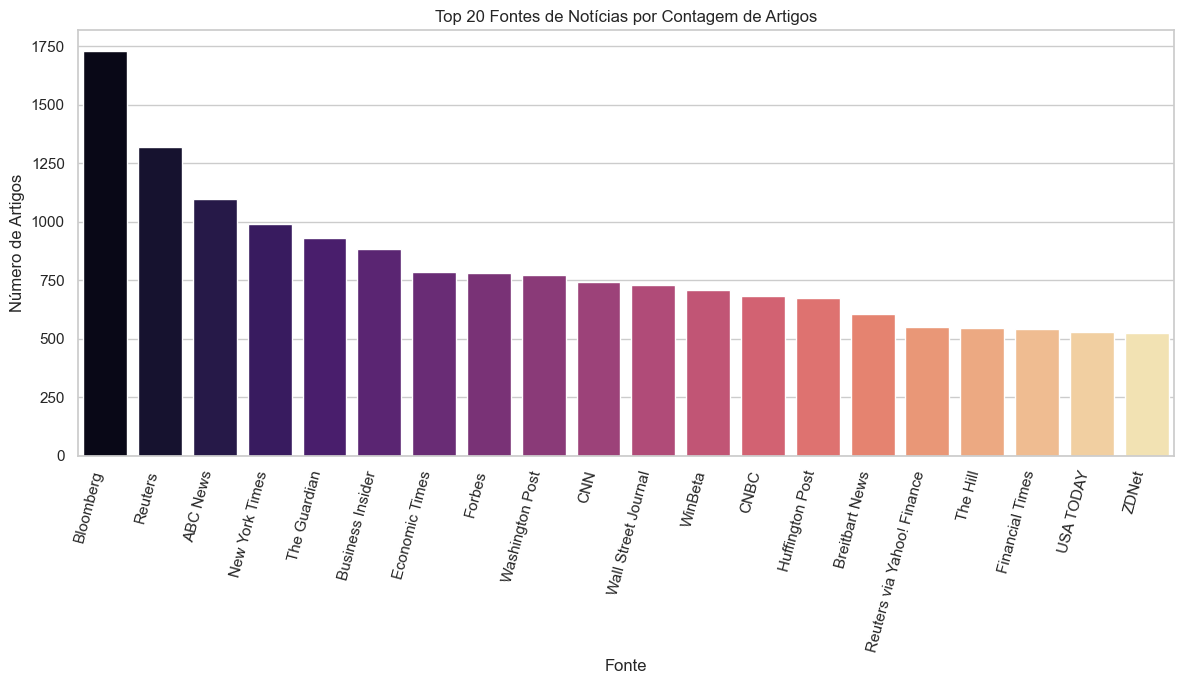

In [5]:

# 5. Análise de Fontes
print("\n--- Análise de Fontes ---")
source_counts = df['Source'].value_counts()
top_n_sources = 20
print(f"Top {top_n_sources} Fontes por Contagem de Artigos:")
print(source_counts.head(top_n_sources))

plt.figure(figsize=(12, 7))
sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)
plt.title(f'Top {top_n_sources} Fontes de Notícias por Contagem de Artigos')
plt.xlabel('Fonte')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()



--- Análise de Sentimento ---


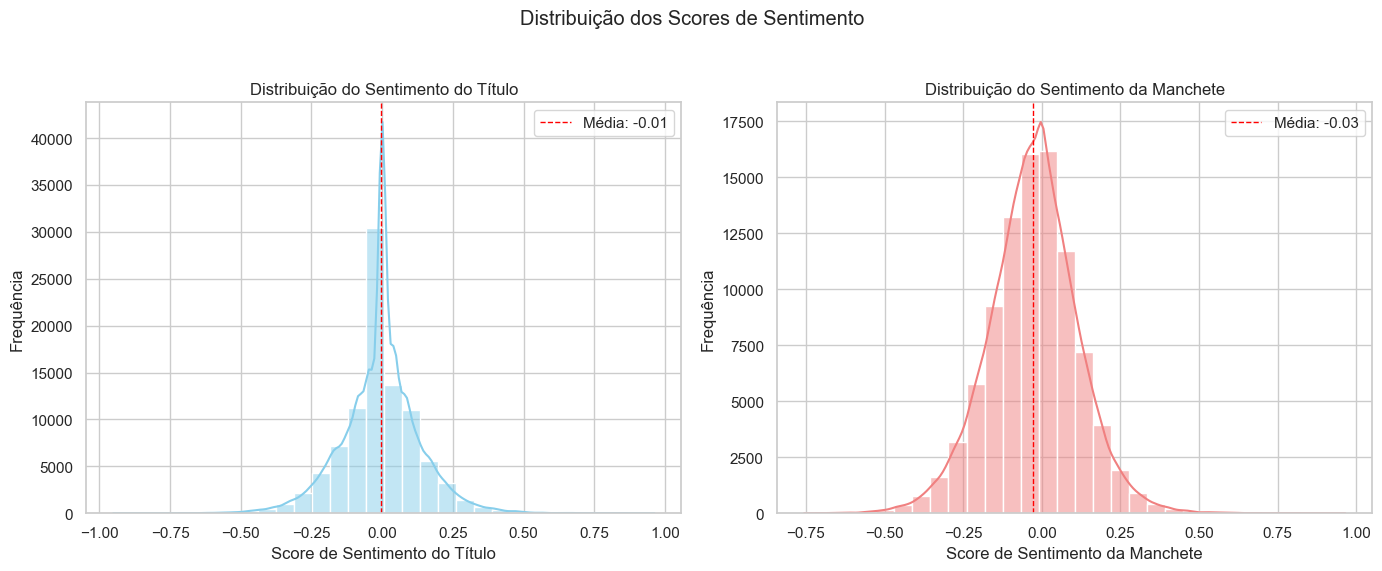


Sentimento Médio por Tópico:
           SentimentTitle  SentimentHeadline
Topic                                       
microsoft        0.002359          -0.014744
obama           -0.000965          -0.017743
economy         -0.010342          -0.039499
palestine       -0.020085          -0.044485


C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\2225861570.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Topic', y='SentimentHeadline', palette='coolwarm', order=order_topics)


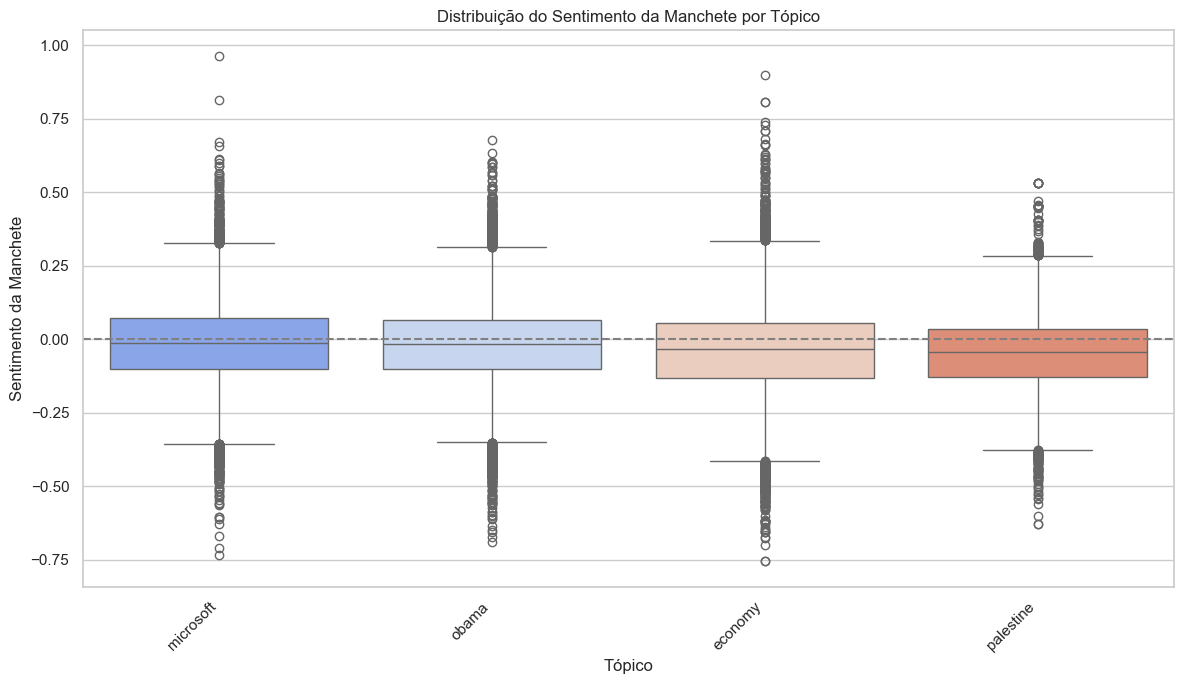

In [6]:

# 6. Análise de Sentimento
print("\n--- Análise de Sentimento ---")

# Distribuição dos Scores de Sentimento
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['SentimentTitle'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Sentimento do Título')
plt.xlabel('Score de Sentimento do Título')
plt.ylabel('Frequência')
plt.axvline(df['SentimentTitle'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Média: {df["SentimentTitle"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df['SentimentHeadline'].dropna(), bins=30, kde=True, color='lightcoral')
plt.title('Distribuição do Sentimento da Manchete')
plt.xlabel('Score de Sentimento da Manchete')
plt.ylabel('Frequência')
plt.axvline(df['SentimentHeadline'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Média: {df["SentimentHeadline"].mean():.2f}')
plt.legend()

plt.suptitle('Distribuição dos Scores de Sentimento')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para o título geral
plt.show()

# Sentimento Médio por Tópico
print("\nSentimento Médio por Tópico:")
avg_sentiment_topic = df.groupby('Topic')[['SentimentTitle', 'SentimentHeadline']].mean().sort_values('SentimentHeadline', ascending=False)
print(avg_sentiment_topic)

# Boxplot de Sentimento da Manchete por Tópico
plt.figure(figsize=(12, 7))
# Ordena os tópicos pela mediana do sentimento para melhor visualização
order_topics = df.groupby('Topic')['SentimentHeadline'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Topic', y='SentimentHeadline', palette='coolwarm', order=order_topics)
plt.title('Distribuição do Sentimento da Manchete por Tópico')
plt.xlabel('Tópico')
plt.ylabel('Sentimento da Manchete')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linestyle='--') # Linha neutra
plt.tight_layout()
plt.show()



--- Análise Temporal ---


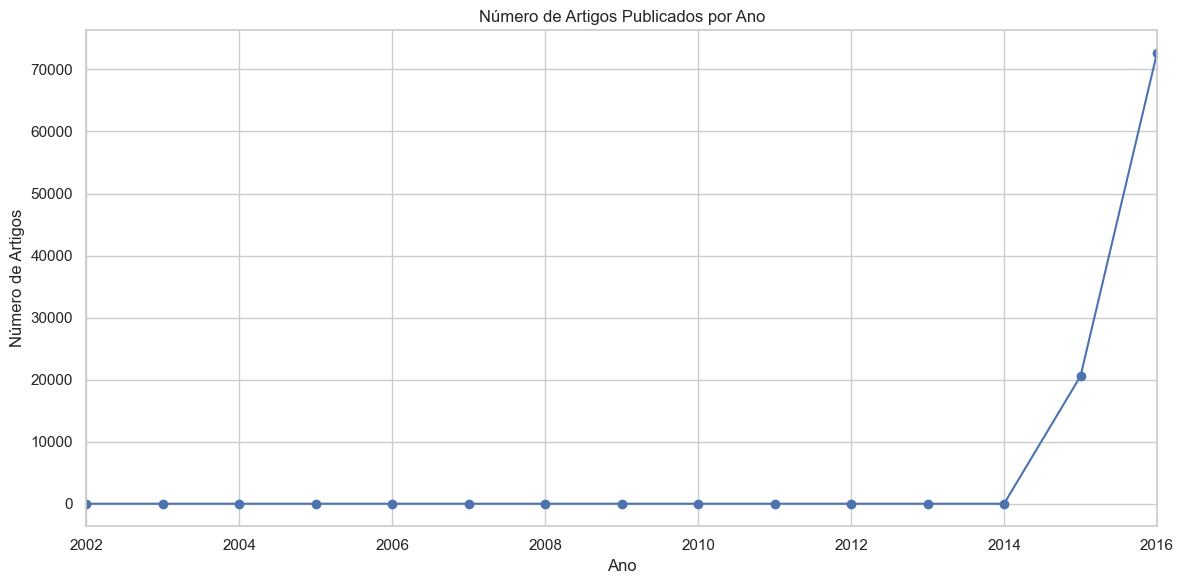

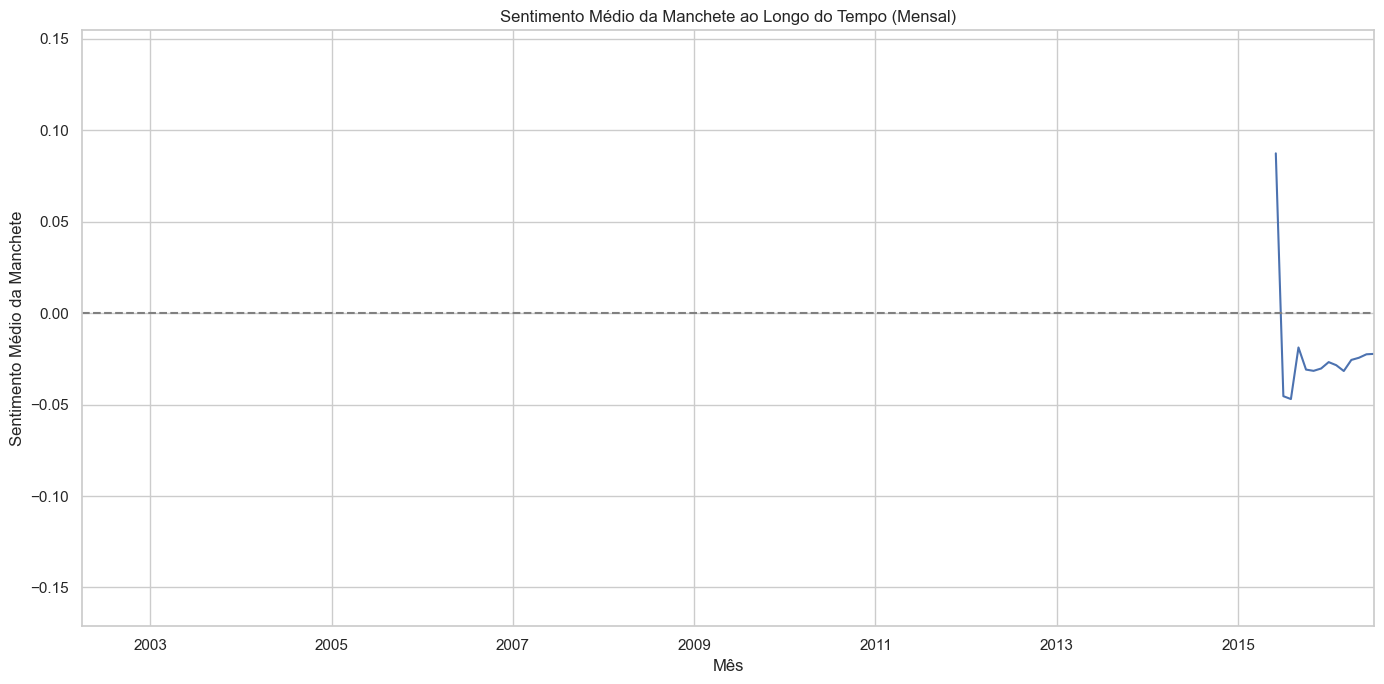

In [7]:

# 7. Análise Temporal
print("\n--- Análise Temporal ---")
# Define 'PublishDate' como índice para facilitar a reamostragem
df_time = df.set_index('PublishDate')

# Número de artigos por ano
plt.figure(figsize=(12, 6))
df_time.resample('YE').size().plot(kind='line', marker='o') # YE = Year End
plt.title('Número de Artigos Publicados por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Artigos')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sentimento médio da manchete ao longo do tempo (mensal)
plt.figure(figsize=(14, 7))
df_time.resample('ME')['SentimentHeadline'].mean().plot(kind='line') # ME = Month End
plt.title('Sentimento Médio da Manchete ao Longo do Tempo (Mensal)')
plt.xlabel('Mês')
plt.ylabel('Sentimento Médio da Manchete')
plt.axhline(0, color='grey', linestyle='--') # Linha neutra
plt.grid(True)
plt.tight_layout()
plt.show()



--- Análise de Redes Sociais ---
Matriz de Correlação (Sentimento vs. Engajamento Social):
                   SentimentTitle  SentimentHeadline  Facebook  GooglePlus  \
SentimentTitle           1.000000           0.183555 -0.003908   -0.010865   
SentimentHeadline        0.183555           1.000000  0.000590    0.001595   
Facebook                -0.003908           0.000590  1.000000    0.518519   
GooglePlus              -0.010865           0.001595  0.518519    1.000000   
LinkedIn                 0.003423           0.006026  0.137959    0.263477   

                   LinkedIn  
SentimentTitle     0.003423  
SentimentHeadline  0.006026  
Facebook           0.137959  
GooglePlus         0.263477  
LinkedIn           1.000000  


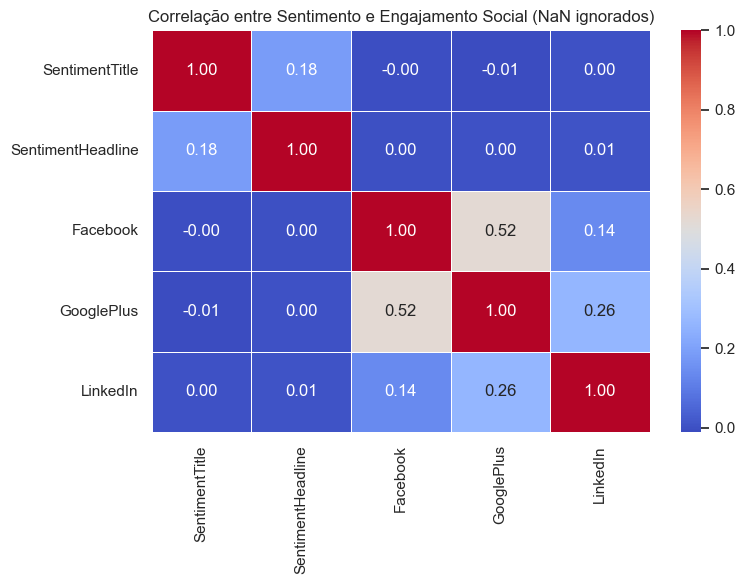


Número de artigos com pelo menos uma métrica social válida (não era -1): 87495 (93.84%)

--- Análise Concluída ---


In [8]:

# 8. Análise de Redes Sociais (Correlação com Sentimento) ---
print("\n--- Análise de Redes Sociais ---")
# Calcula a correlação entre scores de sentimento e contagens de redes sociais
# Nota: .corr() ignora NaN por padrão
correlation_matrix = df[['SentimentTitle', 'SentimentHeadline'] + social_cols].corr()

print("Matriz de Correlação (Sentimento vs. Engajamento Social):")
print(correlation_matrix)

# Visualiza a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Sentimento e Engajamento Social (NaN ignorados)')
plt.tight_layout()
plt.show()

# Contagem de artigos com pelo menos um dado de rede social válido (> -1)
tracked_articles_count = df[social_cols].dropna(how='all').shape[0]
print(f"\nNúmero de artigos com pelo menos uma métrica social válida (não era -1): {tracked_articles_count} ({tracked_articles_count / len(df) * 100:.2f}%)")

print("\n--- Análise Concluída ---")

C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\924297750.py:2: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['BestSocialMedia'] = df[social_cols].idxmax(axis=1)
C:\Users\fabri\AppData\Local\Temp\ipykernel_16324\924297750.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_social_media_counts.index, y=best_social_media_counts.values, palette='pastel')


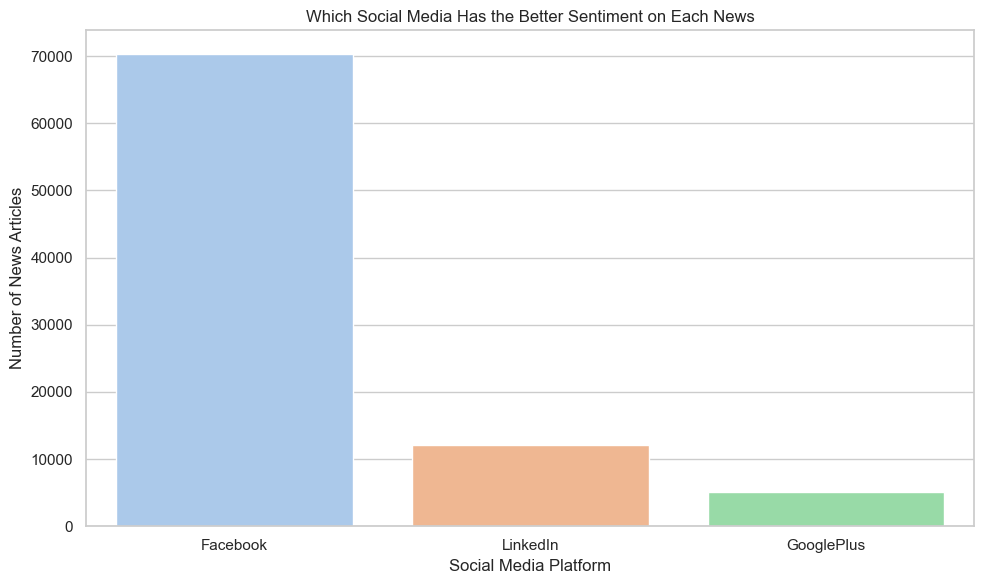

In [ ]:
# Cria uma nova coluna 'BestSocialMedia' que identifica a melhor rede social para cada artigo
# com base no maior valor de engajamento
df['BestSocialMedia'] = df[social_cols].idxmax(axis=1)

# Filtra os artigos que têm pelo menos uma rede social com valor válido
df_filtered = df.dropna(subset=social_cols, how='all')

# Contagem de artigos por melhor rede social
best_social_media_counts = df_filtered['BestSocialMedia'].value_counts()

# Exibe os resultados
plt.figure(figsize=(10, 6))
sns.barplot(x=best_social_media_counts.index, y=best_social_media_counts.values, palette='pastel')
plt.title('Which Social Media Has the Better Sentiment on Each News')
plt.xlabel('Social Media Platform')
plt.ylabel('Number of News Articles')
plt.tight_layout()
plt.show()